In [15]:
import pandas as pd
import numpy as np

In [16]:
df=pd.read_csv(r"C:\Users\Arpit Mehrotra\Desktop\arpit\test_koRSKBP.csv")

print(df.describe())

                  id  marital_status       vintage  claim_amount
count   59595.000000    59595.000000  59595.000000  59595.000000
mean   119190.000000        0.576928      4.620304   4368.504321
std     17203.738983        0.494051      2.282511   3288.132408
min     89393.000000        0.000000      0.000000      0.000000
25%    104291.500000        0.000000      3.000000   2398.000000
50%    119190.000000        1.000000      5.000000   4106.000000
75%    134088.500000        1.000000      6.000000   6104.000000
max    148987.000000        1.000000      8.000000  32534.000000


In [17]:
print(df.isnull().sum())

id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
dtype: int64


In [18]:
df.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
0,89393,Female,Rural,High School,5L-10L,0,6,2134,More than 1,B,Silver
1,89394,Female,Urban,High School,2L-5L,0,4,4102,More than 1,A,Platinum
2,89395,Male,Rural,High School,5L-10L,1,7,2925,More than 1,B,Gold
3,89396,Female,Rural,Bachelor,More than 10L,1,2,0,More than 1,B,Silver
4,89397,Female,Urban,High School,2L-5L,0,5,14059,More than 1,B,Silver


In [19]:
 #code to convert categorial values into machine readable format
from sklearn.preprocessing import LabelEncoder

# List of categorical columns
categorical_cols = ["gender", "area", "qualification", "policy", "type_of_policy"]

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())  # Verify encoding

      id  gender  area  qualification         income  marital_status  vintage  \
0  89393       0     0              1         5L-10L               0        6   
1  89394       0     1              1          2L-5L               0        4   
2  89395       1     0              1         5L-10L               1        7   
3  89396       0     0              0  More than 10L               1        2   
4  89397       0     1              1          2L-5L               0        5   

   claim_amount num_policies  policy  type_of_policy  
0          2134  More than 1       1               2  
1          4102  More than 1       0               1  
2          2925  More than 1       1               0  
3             0  More than 1       1               2  
4         14059  More than 1       1               2  


In [20]:
# Define mapping for income ranges
# converting numerical values in numeric format
income_mapping = {"2L-5L": 3.5, "5L-10L": 7.5, "More than 10L": 12.5}
df["income"] = df["income"].map(income_mapping)

# Convert "num_policies" into binary (1 if more than 1, else 0)
df["num_policies"] = df["num_policies"].apply(lambda x: 1 if x == "More than 1" else 0)

print(df.head())  # Verify changes

      id  gender  area  qualification  income  marital_status  vintage  \
0  89393       0     0              1     7.5               0        6   
1  89394       0     1              1     3.5               0        4   
2  89395       1     0              1     7.5               1        7   
3  89396       0     0              0    12.5               1        2   
4  89397       0     1              1     3.5               0        5   

   claim_amount  num_policies  policy  type_of_policy  
0          2134             1       1               2  
1          4102             1       0               1  
2          2925             1       1               0  
3             0             1       1               2  
4         14059             1       1               2  


In [21]:
# Standardize and map type_of_policy to policy_complexity
policy_complexity = {"silver": 1, "gold": 2, "platinum": 3}

df["policy_complexity"] = (
    df["type_of_policy"]
    .astype(str)  # Ensure all values are strings
    .str.strip()  # Remove extra spaces
    .str.lower()  # Convert to lowercase
    .map(policy_complexity)  # Apply mapping
    .fillna(0)  # Replace unmapped values with 0
)

print(df["policy_complexity"].unique())  # Verify values
# Ensure column is string, strip spaces, and convert to lowercase
df["type_of_policy"] = df["type_of_policy"].astype(str).str.strip().str.lower()

# Define mapping
policy_complexity = {"silver": 1, "gold": 2, "platinum": 3}

# Map values and handle unmapped cases
df["policy_complexity"] = df["type_of_policy"].map(policy_complexity).fillna(0)

# Print unmapped values (if any)
unmapped_values = df[~df["type_of_policy"].isin(policy_complexity.keys())]["type_of_policy"].unique()
print("Unmapped values:", unmapped_values)

print(df["policy_complexity"].unique())

# Check unique values before fixing
print("Unique values in type_of_policy:", df["type_of_policy"].unique())

# Ensure type_of_policy is numeric
df["policy_complexity"] = df["type_of_policy"].astype(int)

# Verify the results
print(df["policy_complexity"].unique())

[0.]
Unmapped values: ['2' '1' '0']
[0.]
Unique values in type_of_policy: ['2' '1' '0']
[2 1 0]


In [22]:
df["churn_risk"] = df.apply(lambda row: 1 if row["vintage"] > 36 and row["claim_ratio"] == 0 else 0, axis=1)
df.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,policy_complexity,churn_risk
0,89393,0,0,1,7.5,0,6,2134,1,1,2,2,0
1,89394,0,1,1,3.5,0,4,4102,1,0,1,1,0
2,89395,1,0,1,7.5,1,7,2925,1,1,0,0,0
3,89396,0,0,0,12.5,1,2,0,1,1,2,2,0
4,89397,0,1,1,3.5,0,5,14059,1,1,2,2,0


In [30]:
import pandas as pd

# Ensure numeric columns are properly typed
df["claim_amount"] = pd.to_numeric(df["claim_amount"], errors="coerce")
df["num_policies"] = pd.to_numeric(df["num_policies"], errors="coerce")
df["vintage"] = pd.to_numeric(df["vintage"], errors="coerce")

# Drop rows with missing key values in 'claim_amount', 'num_policies', or 'vintage'
df.dropna(subset=["claim_amount", "num_policies", "vintage"], inplace=True)

# Step 1: Calculate average revenue per policy
# Avoid division by zero by checking num_policies is greater than 0
df["avg_revenue_per_policy"] = df.apply(
    lambda row: row["claim_amount"] / row["num_policies"] if row["num_policies"] > 0 else 0, axis=1
)

# Step 2: Fill missing avg revenue if any (in case of missing claim_amount or num_policies)
df["avg_revenue_per_policy"].fillna(df["avg_revenue_per_policy"].median(), inplace=True)

# Step 3: Calculate CLV
# CLV formula: avg_revenue_per_policy * num_policies * vintage
df["CLV"] = df["avg_revenue_per_policy"] * df["num_policies"] * df["vintage"]

# Show results for checking
print(df[["id", "avg_revenue_per_policy", "num_policies", "vintage", "CLV"]].head())


      id  avg_revenue_per_policy  num_policies  vintage      CLV
0  89393                  2134.0             1        6  12804.0
1  89394                  4102.0             1        4  16408.0
2  89395                  2925.0             1        7  20475.0
3  89396                     0.0             1        2      0.0
4  89397                 14059.0             1        5  70295.0


C:\Users\Arpit Mehrotra\AppData\Local\Temp\ipykernel_3376\3883401986.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["avg_revenue_per_policy"].fillna(df["avg_revenue_per_policy"].median(), inplace=True)


In [32]:
df.to_csv("clv_enriched_dataset.csv", index=False)
df.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,policy_complexity,churn_risk,avg_revenue_per_policy,CLV
0,89393,0,0,1,7.5,0,6,2134,1,1,2,2,0,2134.0,12804.0
1,89394,0,1,1,3.5,0,4,4102,1,0,1,1,0,4102.0,16408.0
2,89395,1,0,1,7.5,1,7,2925,1,1,0,0,0,2925.0,20475.0
3,89396,0,0,0,12.5,1,2,0,1,1,2,2,0,0.0,0.0
4,89397,0,1,1,3.5,0,5,14059,1,1,2,2,0,14059.0,70295.0


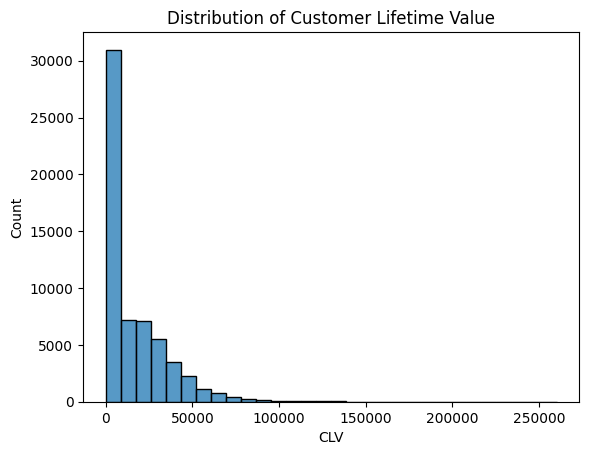

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["CLV"], bins=30)
plt.title("Distribution of Customer Lifetime Value")
plt.show()



In [35]:
df["income"].fillna(df["income"].median())
df["avg_revenue_per_policy"].fillna(df["avg_revenue_per_policy"].median())


0         2134.0
1         4102.0
2         2925.0
3            0.0
4        14059.0
          ...   
59590        0.0
59591        0.0
59592     3323.0
59593     2886.0
59594     5939.0
Name: avg_revenue_per_policy, Length: 59595, dtype: float64

In [36]:
print(df.isnull().sum())  # Should show 0 missing values


id                        0
gender                    0
area                      0
qualification             0
income                    0
marital_status            0
vintage                   0
claim_amount              0
num_policies              0
policy                    0
type_of_policy            0
policy_complexity         0
churn_risk                0
avg_revenue_per_policy    0
CLV                       0
dtype: int64


In [37]:
df["income"] = df["income"].fillna(df["income"].median())
df["avg_revenue_per_policy"] = df["avg_revenue_per_policy"].fillna(df["avg_revenue_per_policy"].median())
df["CLV"] = df["CLV"].fillna(df["CLV"].median())


In [38]:
print(df.isnull().sum())  # Should now show 0 missing values


id                        0
gender                    0
area                      0
qualification             0
income                    0
marital_status            0
vintage                   0
claim_amount              0
num_policies              0
policy                    0
type_of_policy            0
policy_complexity         0
churn_risk                0
avg_revenue_per_policy    0
CLV                       0
dtype: int64


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [40]:
df.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,policy_complexity,churn_risk,avg_revenue_per_policy,CLV
0,89393,0,0,1,7.5,0,6,2134,1,1,2,2,0,2134.0,12804.0
1,89394,0,1,1,3.5,0,4,4102,1,0,1,1,0,4102.0,16408.0
2,89395,1,0,1,7.5,1,7,2925,1,1,0,0,0,2925.0,20475.0
3,89396,0,0,0,12.5,1,2,0,1,1,2,2,0,0.0,0.0
4,89397,0,1,1,3.5,0,5,14059,1,1,2,2,0,14059.0,70295.0


In [42]:
# Selecting relevant features
X = df[["id", "avg_revenue_per_policy", "num_policies", "vintage"]]  # Features
y = df["CLV"]  # Target Variable


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [45]:
model = RandomForestRegressor(n_estimators=100, random_state=42)  # Create model
model.fit(X_train, y_train)  # Train model


RandomForestRegressor(random_state=42)

In [47]:
import numpy as np  # Import NumPy

# Replace missing values with the median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Replace infinite values with the maximum finite value
X_train = X_train.replace([np.inf, -np.inf], X_train.max().max())
X_test = X_test.replace([np.inf, -np.inf], X_test.max().max())

# Check if there are still any NaN or infinite values
print(X_train.isnull().sum())  # Should be all 0 now
print(X_test.isnull().sum())   # Should be all 0 now



id                        0
avg_revenue_per_policy    0
num_policies              0
vintage                   0
dtype: int64
id                        0
avg_revenue_per_policy    0
num_policies              0
vintage                   0
dtype: int64


In [48]:
import numpy as np

# Ensure there are no NaN or infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_test.median())

y_train = y_train.fillna(y_train.median())  # Fill NaN in target variable
y_test = y_test.fillna(y_test.median())  # Fill NaN in test target variable

# Convert data types if needed
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Verify
print(X_train.isnull().sum())  # Should print all 0
print(y_train.isnull().sum())  # Should print 0




id                        0
avg_revenue_per_policy    0
num_policies              0
vintage                   0
dtype: int64
0


In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # Train Model


RandomForestRegressor(random_state=42)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [50]:
# Select relevant features (excluding 'id' and 'CLV' as the target variable)
X = df.drop(columns=["id", "CLV"])  # Features
y = df["CLV"]  # Target variable (Customer Lifetime Value)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")


Training Data: (47676, 13), Testing Data: (11919, 13)


In [52]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # Train Model


RandomForestRegressor(random_state=42)

In [78]:
print(X_train.isnull().sum())  # Check if there are missing values in features
print(y_train.isnull().sum())  # Check if there are missing values in target


gender                    0
area                      0
qualification             0
income                    0
marital_status            0
vintage                   0
claim_amount              0
num_policies              0
policy                    0
type_of_policy            0
policy_complexity         0
churn_risk                0
avg_revenue_per_policy    0
dtype: int64
0


In [60]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


In [80]:
print(X_train.dtypes)



gender                      int64
area                        int64
qualification               int64
income                    float64
marital_status              int64
vintage                     int64
claim_amount                int64
num_policies                int64
policy                      int64
type_of_policy             object
policy_complexity           int64
churn_risk                  int64
avg_revenue_per_policy    float64
dtype: object


In [81]:
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")


In [82]:
print(X_train.isnull().sum())  # Check missing values


gender                    0
area                      0
qualification             0
income                    0
marital_status            0
vintage                   0
claim_amount              0
num_policies              0
policy                    0
type_of_policy            0
policy_complexity         0
churn_risk                0
avg_revenue_per_policy    0
dtype: int64


In [ ]:
# Ensure all data is numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Fill NaN values after conversion
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


In [54]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)


In [55]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Replace infinite values with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Convert to numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Fill missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMAE: {mae}\nRMSE: {rmse}\nR² Score: {r2}")


Model Performance:
MAE: 21.064413121906213
RMSE: 356.9177630859463
R² Score: 0.9996876320142989


In [61]:
# Ensure new_customer has ALL the columns from X_train
new_customer = pd.DataFrame(columns=X_train.columns)

# Fill in example values for prediction (modify as needed)
new_customer.loc[0] = [
    500,    # avg_revenue_per_policy
    3,      # num_policies
    24,     # vintage
    2,      # area
    0.3,    # churn_risk
    1500,   # claim_amount
    1,      # gender (Example: 1 = Male, 0 = Female)
    60000,  # income
    'Bachelor',  # qualification
    'Married',   # marital_status
    'Basic',     # policy
    'Comprehensive',  # type_of_policy
    'High'  # policy_complexity
]

# Convert categorical features using the same encoding as training data
for col in ['qualification', 'marital_status', 'policy', 'type_of_policy', 'policy_complexity']:
    if col in X_train.columns:
        new_customer[col] = new_customer[col].astype('category').cat.codes

# Convert all data to numeric and fill missing values
new_customer = new_customer.apply(pd.to_numeric, errors="coerce")
new_customer = new_customer.fillna(X_train.median())

# Ensure column order matches
new_customer = new_customer[X_train.columns]

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted CLV: {predicted_clv[0]}")



Predicted CLV: 20273.6
